<a href="https://colab.research.google.com/github/Bharani-a123/ML-JOURNEY/blob/main/FoodTruck_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy  as np

In [ ]:
!unzip "/content/drive/MyDrive/ML DATA/FOOD ORDER DATA.zip" -d "/content/ML DATA"


Archive:  /content/drive/MyDrive/ML DATA/FOOD ORDER DATA.zip
  inflating: /content/ML DATA/fast_food_ordering_dataset.csv  


In [ ]:
df=pd.read_csv("/content/ML DATA/fast_food_ordering_dataset.csv")
df.head()

,order_id,order_time,city,cuisine_type,order_value,delivery_time_minutes,payment_method,items_count
0,ORD100000,2025-10-05 21:16:00,Pune,Healthy,867.98,61,UPI,3
1,ORD100001,2025-06-07 09:40:00,Hyderabad,Fast Food,689.71,26,Wallet,3
2,ORD100002,2025-12-20 18:46:00,Chennai,Fast Food,440.48,30,Credit Card,4
3,ORD100003,2025-06-07 14:10:00,Pune,Mexican,995.17,38,Credit Card,6
4,ORD100004,2025-05-11 00:48:00,Bengaluru,Healthy,853.20,33,Debit Card,7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               500 non-null    object 
 1   order_time             500 non-null    object 
 2   city                   500 non-null    object 
 3   cuisine_type           500 non-null    object 
 4   order_value            500 non-null    float64
 5   delivery_time_minutes  500 non-null    int64  
 6   payment_method         500 non-null    object 
 7   items_count            500 non-null    int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 31.4+ KB


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
495,False
496,False
497,False
498,False


In [ ]:
df.isnull().sum()

,0
order_id,0
order_time,0
city,0
cuisine_type,0
order_value,0
delivery_time_minutes,0
payment_method,0
items_count,0


In [ ]:
cat_col=[col for col in df.columns if df[col].dtype==object]
num_col=[col for col in df.columns if df[col].dtype!=object]
print("Categorical column", cat_col)
print("Numerical column", num_col)


Categorical column ['order_id', 'order_time', 'city', 'cuisine_type', 'payment_method']
Numerical column ['order_value', 'delivery_time_minutes', 'items_count']


In [ ]:
from numpy._core.defchararray import upper
x=df['items_count'].mean()
lower_bound=x-2*df['items_count'].std()
upper_bound=x+2*df['items_count'].std()
print(lower_bound)
print(upper_bound)

0.19461352572934176
8.013386474270659


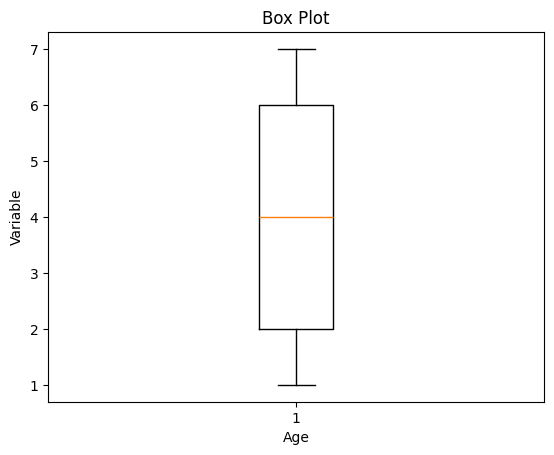

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(df['items_count'])
plt.ylabel('Variable')
plt.xlabel('Age')
plt.title('Box Plot')
plt.show()

In [ ]:

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

num_col_ = [col for col in df.columns if df[col].dtype != 'object']
x1 = df
x1[num_col_] = scaler.fit_transform(x1[num_col_])
x1.head()

,order_id,order_time,city,cuisine_type,order_value,delivery_time_minutes,payment_method,items_count
0,ORD100000,2025-10-05 21:16:00,Pune,Healthy,0.696955,0.779661,UPI,0.333333
1,ORD100001,2025-06-07 09:40:00,Hyderabad,Fast Food,0.534090,0.186441,Wallet,0.333333
2,ORD100002,2025-12-20 18:46:00,Chennai,Fast Food,0.306398,0.254237,Credit Card,0.500000
3,ORD100003,2025-06-07 14:10:00,Pune,Mexican,0.813154,0.389831,Credit Card,0.833333
4,ORD100004,2025-05-11 00:48:00,Bengaluru,Healthy,0.683452,0.305085,Debit Card,1.000000
